In [1]:
# These modules are required for the data reduction.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u

# This module is used for custom plotting.
import matplotlib.pyplot as plt

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(example="align")

15:57:52.140 I Resolving example=align -> mixed-fs-ps/data/TGBT24B_613_04.raw.vegas.trim.fits


15:57:52.141 I url: http://www.gb.nrao.edu/dysh//example_data/mixed-fs-ps/data/TGBT24B_613_04.raw.vegas.trim.fits


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/mixed-fs-ps/data/TGBT24B_613_04.raw.vegas.trim.fits
TGBT24B_613_04.raw.vegas.trim.fits already downloaded


In [4]:
sdf = GBTFITSLoad(filename)

In [5]:
sdf.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
35,MESSIER32,-200.0,OnOff,1,1.420406,1,1,5,1,73.1155,62.2955
36,MESSIER32,-200.0,OnOff,2,1.420406,1,1,5,1,72.3087,59.3225


In [6]:
# Signal.
ps_sig = sdf.getps(scan=35, sig="T", ifnum=0, plnum=0, fdnum=0).timeaverage()
# Reference.
ps_ref = sdf.getps(scan=35, sig="F", ifnum=0, plnum=0, fdnum=0).timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


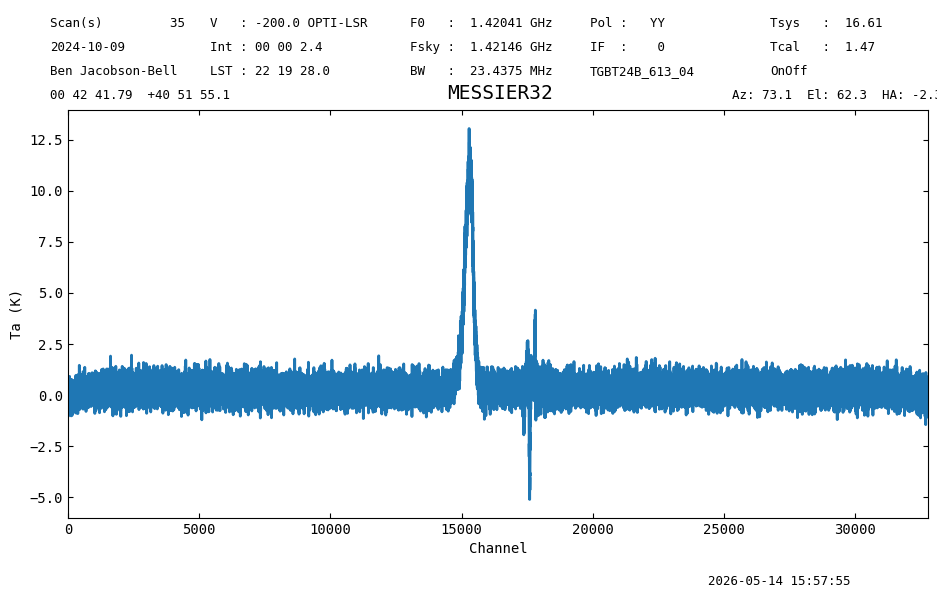

In [7]:
p1 = ps_sig.plot(xaxis_unit="chan")
p1.oshow(ps_ref)

In [8]:
print(f"Noise on the signal state {ps_sig[5000:10000].stats()['rms']:.2f}")
print(f"Noise on the reference state {ps_ref[5000:10000].stats()['rms']:.2f}")

Noise on the signal state 0.41 K
Noise on the reference state 0.40 K


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


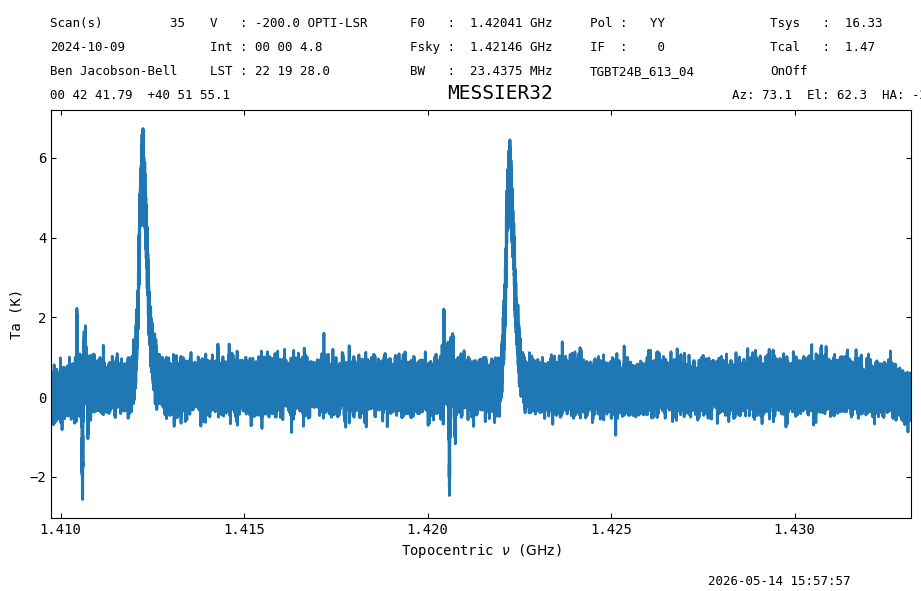

In [9]:
ps = sdf.getps(scan=35, fdnum=0, plnum=0, ifnum=0).timeaverage()
ps.plot(xaxis_unit="GHz");

In [10]:
ps_ref_aligned = ps_ref.align_to(ps_sig)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


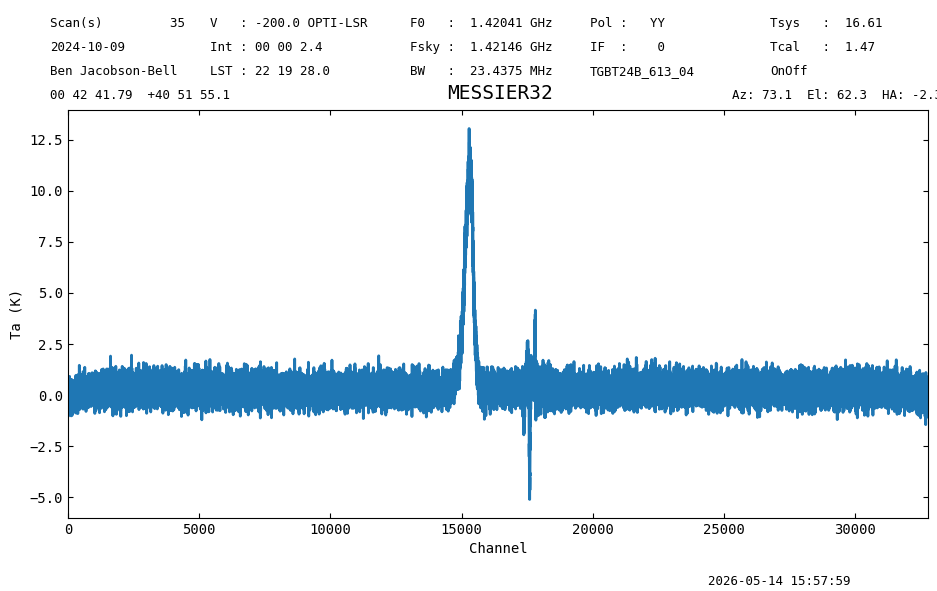

In [11]:
p1 = ps_sig.plot(xaxis_unit="chan")
p1.oshow(ps_ref_aligned)

In [12]:
ps_avg = ps_sig.average(ps_ref_aligned)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


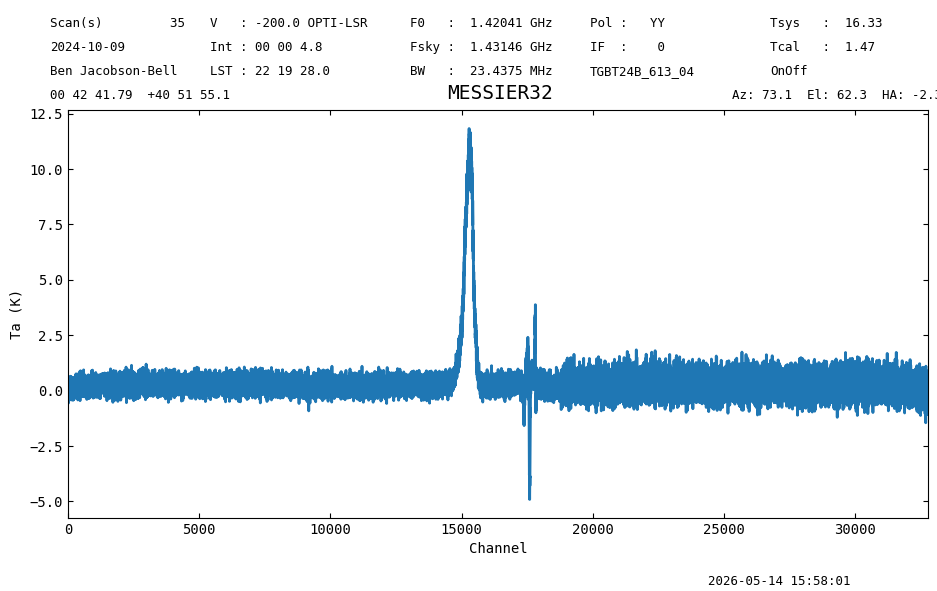

In [13]:
ps_avg.plot(xaxis_unit="chan");

In [14]:
print(f"Noise on the average {ps_avg[5000:10000].stats()['rms']:.2f}")

Noise on the average 0.26 K


In [15]:
ps_avg.check_stats(1.03823425 * u.K)

15:58:02.689 I rms is OK 
